In [1]:
import numpy as np
import pandas as pd
from numpy.random import default_rng

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.multioutput import MultiOutputClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler



In [2]:
!pip install matplotlib-venn

In [3]:
!pip install venn

In [36]:
import pandas as pd
from sqlalchemy import create_engine
import tools.helpers as hh
import matplotlib.pyplot as plt
from matplotlib_venn import venn3
from venn import venn

In [37]:
pd.set_option('display.max_columns', None)

In [41]:
feature_df=pd.read_parquet("/Users/gnaanikko.pa/Documents/Academic /MIMIC/model_building/parq/feature_df_final.parq") 

In [42]:
feature_df

,stay_id,50983,50971,50902,50931,50912,51222,51221,51301,50960,50970,Antibiotic,gender,anchor_age,anchor_year,race,icu_los_days,icu_admit_time,icu_discharge_time,Antibiotic_Standardized,Antibiotic_Class,org_name,interpretation
index,,,,,,,,,,,,,,,,,,,,,,,
0,30004391,141.0,4.7,115.0,138.0,1.3,9.9,30.6,13.5,2.1,3.8,TOBRAMYCIN,M,89,2153,WHITE,8.214792,2153-09-05 13:12:00,2153-09-13 18:21:18,TOBRAMYCIN,Aminoglycoside,KLEBSIELLA PNEUMONIAE,S
3,30017005,135.0,5.2,98.0,148.0,4.5,9.6,32.1,37.6,2.1,5.5,VANCOMYCIN,M,39,2186,WHITE,63.086343,2190-03-11 14:04:02,2190-05-13 16:08:22,VANCOMYCIN,Glycopeptide,STAPH AUREUS COAG +,S
4,30017005,135.0,5.2,98.0,148.0,4.5,9.6,32.1,37.6,2.1,5.5,VANCOMYCIN,M,39,2186,WHITE,63.086343,2190-03-11 14:04:02,2190-05-13 16:08:22,VANCOMYCIN,Glycopeptide,STAPH AUREUS COAG +,S
5,30017005,135.0,5.2,98.0,148.0,4.5,9.6,32.1,37.6,2.1,5.5,VANCOMYCIN,M,39,2186,WHITE,63.086343,2190-03-11 14:04:02,2190-05-13 16:08:22,VANCOMYCIN,Glycopeptide,STAPH AUREUS COAG +,S
15,30071339,142.0,3.6,97.0,65.0,0.2,7.5,25.2,8.1,1.8,2.9,TOBRAMYCIN,F,66,2149,BLACK/AFRICAN AMERICAN,49.181597,2161-11-28 15:03:54,2162-01-16 19:25:24,TOBRAMYCIN,Aminoglycoside,PSEUDOMONAS AERUGINOSA,S
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2343,39939179,158.0,3.4,125.0,106.0,2.1,13.0,42.8,8.2,1.7,5.4,LEVOFLOXACIN,F,56,2169,WHITE,7.617766,2169-10-15 05:03:00,2169-10-22 19:52:35,LEVOFLOXACIN,Fluoroquinolone,STAPH AUREUS COAG +,S
2344,39947325,131.0,4.0,87.0,108.0,0.6,10.8,33.4,11.1,2.0,2.7,VANCOMYCIN,M,61,2177,UNKNOWN,1.853808,2177-12-08 02:59:00,2177-12-09 23:28:29,VANCOMYCIN,Glycopeptide,STAPH AUREUS COAG +,S
2347,39965130,140.0,4.6,102.0,137.0,2.1,10.5,32.8,53.4,3.2,6.0,AMPICILLIN,M,55,2186,WHITE,12.533067,2186-09-02 09:28:03,2186-09-14 22:15:40,AMPICILLIN,Penicillin,ENTEROCOCCUS FAECALIS,S


In [18]:
feature_df.stay_id.nunique()

460

In [19]:
itemid_name_map = {
    '50983': 'Potassium',
    '50971': 'Sodium',
    '50902': 'Bicarbonate',
    '50931': 'Chloride',
    '50912': 'Calcium',
    '51222': 'WBC',
    '51221': 'RBC',
    '51301': 'Platelet',
    '50960': 'Glucose',
    '50970': 'Creatinine'
}
feature_df.rename(columns=itemid_name_map, inplace=True)

In [9]:
# anchor_year,icu_los_days,icu_discharge_time,icu_admit_time,Antibiotic_Standardized,Antibiotic_Class,org_name

In [10]:
feature_df.org_name.value_counts()

org_name
PSEUDOMONAS AERUGINOSA                              186
KLEBSIELLA PNEUMONIAE                               128
ESCHERICHIA COLI                                    118
STAPH AUREUS COAG +                                 108
SERRATIA MARCESCENS                                  38
ENTEROBACTER AEROGENES                               26
PROTEUS MIRABILIS                                    22
ENTEROBACTER CLOACAE COMPLEX                         22
ACINETOBACTER BAUMANNII COMPLEX                      18
ENTEROCOCCUS SP.                                     15
ENTEROCOCCUS FAECIUM                                 12
ACHROMOBACTER SP.                                     9
STAPHYLOCOCCUS, COAGULASE NEGATIVE                    8
STREPTOCOCCUS PNEUMONIAE                              7
KLEBSIELLA OXYTOCA                                    7
ENTEROCOCCUS FAECALIS                                 7
STAPHYLOCOCCUS EPIDERMIDIS                            6
STREPTOCOCCUS ANGINOSUS (MILLERI) GROUP

In [ ]:

lab_df= pd.read_parquet("common_resp_lab_icu_inf_df.parquet", engine="fastparquet")
ast_df= pd.read_parquet("common_resp_ast_icu_inf_df.parquet", engine="fastparquet")
pres_df= pd.read_parquet("common_resp_pres_icu_inf_df.parquet", engine="fastparquet")
emar_df= pd.read_parquet("common_resp_emar_icu_inf_df.parquet", engine="fastparquet")
input_df= pd.read_parquet("common_resp_input_icu_inf_df.parquet", engine="fastparquet")
micro_df= pd.read_parquet("common_resp_micro_icu_inf_df.parquet", engine="fastparquet")
lab_test_icu_df= pd.read_parquet("lab_test_icu_df.parq", engine="fastparquet")

In [13]:
main_cohort_df= pd.read_csv("/Users/gnaanikko.pa/Documents/Academic Projects/model_building/common_hadm_ids_1k.csv")
 

In [14]:
main_cohort_df.head()

,hadm_id
0,20103175
1,27295762
2,23674901
3,26066966
4,21962778


In [15]:
admissions_df= pd.read_parquet("/Users/gnaanikko.pa/Documents/Academic Projects/model_building/df_admissions.parq", engine="fastparquet")


In [16]:
t_sub_df=hh.df_subset(admissions_df,main_cohort_df,'hadm_id')

In [17]:
hh.dxx(t_sub_df)

1.4k Unique Patient IDs (1433)
1.5k Unique Admission IDs (1512)
2.1k Unique ICU Stay IDs (2066)
2.1k Rows, shape: (2066, 16)



,subject_id,gender,anchor_age,anchor_year,hadm_id,hospital_admit_time,hospital_discharge_time,hospital_death_time,stay_id,icu_admit_time,icu_discharge_time,icu_los_days,admission_type,admission_location,discharge_location,race
dtype,int64,object,int64,int64,int64,datetime64[ns],datetime64[ns],datetime64[ns],int64,datetime64[ns],datetime64[ns],float64,object,object,object,object
NotNA | NA,2066 | 0,2066 | 0,2066 | 0,2066 | 0,2066 | 0,2066 | 0,2066 | 0,569 | 1497,2066 | 0,2066 | 0,2066 | 0,2066 | 0,2066 | 0,2066 | 0,2064 | 2,2066 | 0
nunique,1433,2,73,93,1512,1511,1512,413,2066,2066,2066,2063,8,10,12,29
25,10545747,M,74,2152,25020409,2152-09-17 23:47:00,2152-09-27 15:55:00,2152-09-27 15:55:00,34649276,2152-09-17 23:48:26,2152-09-27 17:46:13,9.748461,URGENT,TRANSFER FROM HOSPITAL,DIED,WHITE
28,10688793,M,50,2185,29890729,2185-01-16 02:31:00,2185-01-21 18:32:00,2185-01-21 18:32:00,39099431,2185-01-16 02:33:04,2185-01-21 21:00:06,5.768773,URGENT,TRANSFER FROM HOSPITAL,DIED,WHITE
33,10745745,M,69,2182,20195310,2182-12-13 22:28:00,2182-12-27 17:20:00,NaT,36351539,2182-12-13 22:29:43,2182-12-27 17:20:19,13.785139,URGENT,TRANSFER FROM HOSPITAL,CHRONIC/LONG TERM ACUTE CARE,WHITE


In [35]:
import random
pt=random.choice(t_sub_df.stay_id.unique())
hh.df_sample(t_sub_df,item=pt,by_col='stay_id')

,subject_id,gender,anchor_age,anchor_year,hadm_id,hospital_admit_time,hospital_discharge_time,hospital_death_time,stay_id,icu_admit_time,icu_discharge_time,icu_los_days,admission_type,admission_location,discharge_location,race
5218,15346643,M,53,2116,20579801,2116-08-22 19:57:00,2116-08-30 17:00:00,NaT,35090996,2116-08-22 19:58:25,2116-08-26 00:00:59,3.168449,URGENT,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,OTHER


In [20]:
feature_df=feature_df[['stay_id', 'Potassium', 'Sodium', 'Bicarbonate', 'Chloride', 'Calcium',
       'WBC', 'RBC', 'Platelet', 'Glucose', 'Creatinine', 'Antibiotic',
       'gender', 'anchor_age', 'race',  'interpretation']]

In [21]:
input_df.ordercategoryname.unique()

NameError: name 'input_df' is not defined

In [33]:
input_df[input_df['ordercategoryname'].str.contains('Prophylaxis',case=False)].label.unique()


array(['Heparin Sodium (Prophylaxis)', 'Lansoprazole (Prevacid)',
       'Solution', 'Pantoprazole (Protonix)', 'Famotidine (Pepcid)',
       'Omeprazole (Prilosec)', 'Coumadin (Warfarin)',
       'Ranitidine (Prophylaxis)', 'Fondaparinux', 'NaCl 0.9%',
       'Esomeprazole (Nexium)', 'Carafate (Sucralfate)',
       'Enoxaparin (Lovenox)'], dtype=object)

In [30]:
input_ab_df= input_df[input_df['ordercategoryname'].str.contains('antibiotics',case=False)]

In [ ]:
# 35090996, 36496642

In [79]:
import random
pt=random.choice(t_sub_df.stay_id.unique())
hh.df_sample(t_sub_df,item=pt,by_col='stay_id')

,subject_id,gender,anchor_age,anchor_year,hadm_id,hospital_admit_time,hospital_discharge_time,hospital_death_time,stay_id,icu_admit_time,icu_discharge_time,icu_los_days,admission_type,admission_location,discharge_location,race
6276,17862835,M,59,2154,26580032,2163-07-03 21:54:00,2163-07-12 08:52:00,2163-07-12 08:52:00,37292063,2163-07-05 22:51:26,2163-07-12 11:19:48,6.519699,OBSERVATION ADMIT,PHYSICIAN REFERRAL,DIED,BLACK/AFRICAN AMERICAN


In [80]:
print('stay_id',pt)
print('pt_received antibiotics:')
print(hh.df_sample(input_ab_df,item=pt,by_col='stay_id').label.unique())
print('antibiotic_in_ast_result:')
print(hh.df_sample(ast_df,item=pt,by_col='stay_id').ab_name.unique())

stay_id 37292063
pt_received antibiotics:
['Dextrose 5%' 'Vancomycin' 'Piperacillin/Tazobactam (Zosyn)'
 'Clindamycin' 'Piperacillin' 'NaCl 0.9%' 'Cefepime']
antibiotic_in_ast_result:
['TRIMETHOPRIM/SULFA' 'NITROFURANTOIN' 'GENTAMICIN' 'TOBRAMYCIN'
 'CEFTAZIDIME' 'CEFTRIAXONE' 'CIPROFLOXACIN' 'PIPERACILLIN/TAZO'
 'CEFEPIME' 'MEROPENEM' 'AMPICILLIN' 'AMPICILLIN/SULBACTAM']


In [81]:
hh.df_sample(feature_df,item=pt,by_col='stay_id')

,stay_id,Potassium,Sodium,Bicarbonate,Chloride,Calcium,WBC,RBC,Platelet,Glucose,Creatinine,Antibiotic,gender,anchor_age,anchor_year,race,icu_los_days,icu_admit_time,icu_discharge_time,Antibiotic_Standardized,Antibiotic_Class,org_name,interpretation
index,,,,,,,,,,,,,,,,,,,,,,,
1689,37292063,138.0,3.9,99.0,184.0,4.8,8.9,28.6,21.4,2.1,3.6,CEFEPIME,M,59,2154,BLACK/AFRICAN AMERICAN,6.519699,2163-07-05 22:51:26,2163-07-12 11:19:48,CEFEPIME,Cephalosporin,ENTEROBACTER AEROGENES,S
1690,37292063,138.0,3.9,99.0,184.0,4.8,8.9,28.6,21.4,2.1,3.6,CEFEPIME,M,59,2154,BLACK/AFRICAN AMERICAN,6.519699,2163-07-05 22:51:26,2163-07-12 11:19:48,CEFEPIME,Cephalosporin,PROTEUS MIRABILIS,S


In [62]:
feature_df[feature_df['stay_id']==36496642]

,stay_id,Potassium,Sodium,Bicarbonate,Chloride,Calcium,WBC,RBC,Platelet,Glucose,Creatinine,Antibiotic,gender,anchor_age,anchor_year,race,icu_los_days,icu_admit_time,icu_discharge_time,Antibiotic_Standardized,Antibiotic_Class,org_name,interpretation
index,,,,,,,,,,,,,,,,,,,,,,,


In [ ]:
hh.df_sample(feature_df,item=pt,by_col='stay_id')

,stay_id,Potassium,Sodium,Bicarbonate,Chloride,Calcium,WBC,RBC,Platelet,Glucose,Creatinine,Antibiotic,gender,anchor_age,anchor_year,race,icu_los_days,icu_admit_time,icu_discharge_time,Antibiotic_Standardized,Antibiotic_Class,org_name,interpretation
index,,,,,,,,,,,,,,,,,,,,,,,


In [11]:
feature_df.columns

Index(['stay_id', '50983', '50971', '50902', '50931', '50912', '51222',
       '51221', '51301', '50960', '50970', 'Antibiotic', 'gender',
       'anchor_age', 'anchor_year', 'race', 'icu_los_days', 'icu_admit_time',
       'icu_discharge_time', 'Antibiotic_Standardized', 'Antibiotic_Class',
       'org_name', 'interpretation'],
      dtype='object')

In [22]:
feature_df['interpretation'] = feature_df['interpretation'].replace('I', 'R')

/var/folders/83/nr7h56f573z_vnkxbhjqb9tc0000gr/T/ipykernel_97421/179741648.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  feature_df['interpretation'] = feature_df['interpretation'].replace('I', 'R')


In [23]:
input_col=['Potassium', 'Sodium', 'Bicarbonate', 'Chloride', 'Calcium',
       'WBC', 'RBC', 'Platelet', 'Glucose', 'Creatinine', 'Antibiotic',
       'gender', 'anchor_age', 'race']

output_col=['interpretation'] 


In [24]:
num_cols=['Potassium', 'Sodium', 'Bicarbonate', 'Chloride', 'Calcium',
       'WBC', 'RBC', 'Platelet', 'Glucose', 'Creatinine', 'anchor_age']

In [25]:


X = feature_df[input_col]
y = pd.DataFrame({
    "susceptible": feature_df["interpretation"]
})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)


In [26]:
num_cols_df= feature_df[num_cols] 

In [27]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(num_cols_df)

In [28]:
df_scaled = pd.DataFrame(scaled_data, columns=num_cols_df.columns)

In [29]:
df_scaled

,Potassium,Sodium,Bicarbonate,Chloride,Calcium,WBC,RBC,Platelet,Glucose,Creatinine,anchor_age
0,0.385691,0.472231,1.811309,-0.232252,-0.259279,0.094582,-0.000980,-0.167436,0.108576,-0.150972,1.876235
1,-0.552123,1.113886,-0.479192,-0.121313,1.936310,-0.045248,0.230507,1.684933,0.108576,0.826692,-1.614208
2,-0.552123,1.113886,-0.479192,-0.121313,1.936310,-0.045248,0.230507,1.684933,0.108576,0.826692,-1.614208
3,-0.552123,1.113886,-0.479192,-0.121313,1.936310,-0.045248,0.230507,1.684933,0.108576,0.826692,-1.614208
4,0.541994,-0.939408,-0.613928,-1.042104,-1.014013,-1.024061,-0.834337,-0.582489,-0.545371,-0.668558,0.270631
...,...,...,...,...,...,...,...,...,...,...,...
782,3.042832,-1.196070,3.158663,-0.587255,0.289618,1.539497,1.881787,-0.574803,-0.763353,0.769182,-0.427457
783,-1.177332,-0.426085,-1.961281,-0.565068,-0.739564,0.514074,0.431130,-0.351904,-0.109407,-0.783578,-0.078413
784,0.229389,0.343901,0.059749,-0.243346,0.289618,0.374243,0.338535,2.899349,2.506381,1.114240,-0.497266
785,0.229389,0.343901,0.059749,-0.243346,0.289618,0.374243,0.338535,2.899349,2.506381,1.114240,-0.497266


In [30]:
num_cols = ['Potassium', 'Sodium', 'Bicarbonate', 'Chloride', 'Calcium',
       'WBC', 'RBC', 'Platelet', 'Glucose', 'Creatinine','anchor_age']  # numeric columns
cat_cols = ["gender", "race", 'Antibiotic']  # categorical columns

pre = ColumnTransformer(  # define column-wise preprocessing
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),  # one-hot encode categoricals
        ("num",  'passthrough', num_cols),  
    ],
    remainder="drop",  # drop any unspecified columns (e.g., patient_id)
)

In [35]:
!pip install xgboost
!pip install lightgbm
!pip install catboost



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
   25l   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/1.6 MB ? eta -:--:--━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 11.9 MB/s  0:00:00

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
   25l   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/27.8 MB ? eta -:--:--━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/27.8 MB 13.9 MB/s eta 0:00:02━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/27.8 MB 10.4 MB/s eta 0:00:03━━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/27.8 MB 11.7 MB/s eta 0:00:02━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/27.8 MB 11.9 MB/s eta 0:00:02━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━ 11.3/27.8 MB 11.2 MB/s eta 0:00:02━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━ 13.6/27.8 MB 11.4 MB/s eta 0:00:02━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━ 15.2/27.8 MB 10.7 MB/s eta 0:00:02━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━

ModuleNotFoundError: No module named 'xgboost'

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.multioutput import MultiOutputClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

def preprocess_features(cat_cols, num_cols):
    pre = ColumnTransformer(  # define column-wise preprocessing
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),  # one-hot encode categoricals
        ("num",  'passthrough', num_cols),  
    ],
    remainder="drop",  # drop any unspecified columns (e.g., patient_id)
    )
def classifier_rf():
    base = RandomForestClassifier(
    n_estimators=300, max_depth=None, random_state=42, n_jobs=-1)
    pipe = Pipeline([("pre", pre), ("model",base)])

    return pipe

def classifier_xgb():
    pre = ColumnTransformer(  # define column-wise preprocessing
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),  # one-hot encode categoricals
        ("num",  'passthrough', num_cols),  
    ],
    remainder="drop",  # drop any unspecified columns (e.g., patient_id)
)
    base = XGBClassifier(
        n_estimators=300, max_depth=None, random_state=42, n_jobs=-1)
    pipe = Pipeline([("pre", pre), ("model",base)])
    return pipe


def classifier_lgb():
    pre = ColumnTransformer(  # define column-wise preprocessing
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),  # one-hot encode categoricals
        ("num",  'passthrough', num_cols),  
    ],
    remainder="drop",  )
    base = lgb.LGBMClassifier(
        n_estimators=300, max_depth=None, random_state=42, n_jobs=-1)
    pipe = Pipeline([("pre", pre), ("model",base)])
    return pipe

def classifier_cb():
    pre = ColumnTransformer(  # define column-wise preprocessing
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),  # one-hot encode categoricals
        ("num",  'passthrough', num_cols),  
    ],
    remainder="drop",  )
    base = cb.CatBoostClassifier(
        n_estimators=300, max_depth=None, random_state=42, n_jobs=-1)
    pipe = Pipeline([("pre", pre), ("model",base)])
    return pipe

def classifier_svm():
    pre = ColumnTransformer(  # define column-wise preprocessing
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),  # one-hot encode categoricals
        ("num",  'passthrough', num_cols),  
    ],
    remainder="drop",  )
    base = SVC(kernel='linear')
    pipe = Pipeline([("pre", pre), ("model",base)])
    return pipe
def multiclass_classification(model, X_train, y_train, X_test, y_test, labels=None, average="macro"):
    """

In [ ]:
pipe2 = classifier_rf()
pipe2.fit(X_train, y_train)

In [31]:
base = RandomForestClassifier(
    n_estimators=300, max_depth=None, random_state=42, n_jobs=-1
)
pipe = Pipeline([("pre", pre), ("model",base)])

x=pipe.fit(X_train, y_train)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [32]:
x

,steps,"[('pre', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [25]:
# sklearn.base.BaseEstimator.predict: generate predictions for both targets
pred = pipe.predict(X_test)

# pandas.DataFrame: align predictions with target column names for metric calls
pred_df = pd.DataFrame(pred, columns=y_train.columns)

# sklearn.metrics.accuracy_score: proportion of correct predictions

acc_susc = accuracy_score(y_test["susceptible"], pred_df["susceptible"])

print(f"Susceptible accuracy: {acc_susc:.3f}")

# sklearn.metrics.classification_report: precision/recall/F1 summary for binary susceptibility
print("\nSusceptible classification report:\n")
print(classification_report(y_test["susceptible"], pred_df["susceptible"]))


Susceptible accuracy: 0.695

Susceptible classification report:

              precision    recall  f1-score   support

           R       0.67      0.29      0.40        70
           S       0.70      0.92      0.80       127

    accuracy                           0.70       197
   macro avg       0.68      0.60      0.60       197
weighted avg       0.69      0.70      0.66       197



In [26]:
y_score = pipe.predict_proba(X_test)
y_score

array([[0.17979969, 0.82020031],
       [0.04583333, 0.95416667],
       [0.43586364, 0.56413636],
       [0.21588889, 0.78411111],
       [0.393788  , 0.606212  ],
       [0.73053571, 0.26946429],
       [0.23805556, 0.76194444],
       [0.99666667, 0.00333333],
       [0.21142593, 0.78857407],
       [0.1462381 , 0.8537619 ],
       [0.2655    , 0.7345    ],
       [0.38480159, 0.61519841],
       [0.14068783, 0.85931217],
       [0.7282619 , 0.2717381 ],
       [0.21253968, 0.78746032],
       [0.19435185, 0.80564815],
       [0.29688095, 0.70311905],
       [0.75867905, 0.24132095],
       [0.32067857, 0.67932143],
       [0.31364683, 0.68635317],
       [0.09888889, 0.90111111],
       [0.16861111, 0.83138889],
       [0.16266667, 0.83733333],
       [0.92166667, 0.07833333],
       [0.19488095, 0.80511905],
       [0.05222222, 0.94777778],
       [0.00333333, 0.99666667],
       [0.32261111, 0.67738889],
       [0.14791667, 0.85208333],
       [0.4157963 , 0.5842037 ],
       [0.

In [27]:
import numpy as np
import matplotlib.pyplot as plt
# Matplotlib "Nature-ish" style
plt.rcParams.update({
    "figure.dpi": 200,
    "savefig.dpi": 300,
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "axes.labelsize": 14,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 1.0,
    "legend.frameon": False,
    "legend.fontsize": 10,
    "xtick.direction": "out",
    "ytick.direction": "out",
})







In [28]:

from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    auc,
    roc_curve,
)
from sklearn.preprocessing import label_binarize


def evaluate_classifier(
    y_true,
    y_pred,
    y_score,
    labels=None,
    title="Confusion Matrix",
    plot_cm=True,
    cm_normalize="true",
    plot_curves=True,
):
    """
    Evaluate binary or multiclass classifier performance:
    - AUROC, AUPRC (macro/micro + per-class)
    - Confusion matrix (with cell values)
    - ROC and PR curves (per class + macro)

    Parameters
    ----------
    y_true : array-like, true class labels
    y_pred : array-like, predicted class labels
    y_score : array-like, predicted probabilities (n_samples, n_classes)
    labels : list of class labels (order must match y_score columns)
    title : str, title for confusion matrix
    plot_cm : bool, whether to plot confusion matrix
    cm_normalize : str or None, normalization ('true', 'pred', 'all', or None)
    plot_curves : bool, whether to plot ROC and PR curves

    Returns
    -------
    metrics : dict of computed scores
    cm : ndarray, confusion matrix
    fig_cm, fig_roc, fig_pr : matplotlib Figure objects
    """

    unique_labels = np.unique(y_true)
    n_classes = len(unique_labels)
    metrics = {}

    if labels is None:
        labels = unique_labels

    # Binarize for multi-class case
    y_true_bin = label_binarize(y_true, classes=labels) if n_classes > 2 else y_true

    # --- AUROC / AUPRC Computation ---
    if n_classes > 2:
        # Overall
        metrics["macro_auroc"] = roc_auc_score(y_true_bin, y_score, average="macro", multi_class="ovr")
        metrics["micro_auroc"] = roc_auc_score(y_true_bin, y_score, average="micro", multi_class="ovr")

        # Per-class AUROC and AUPRC
        pr_aucs = []
        metrics["per_class"] = {}
        for i, cls in enumerate(labels):
            precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_score[:, i])
            auprc = auc(recall, precision)
            pr_aucs.append(auprc)
            try:
                auroc = roc_auc_score(y_true_bin[:, i], y_score[:, i])
            except ValueError:
                auroc = np.nan
            metrics["per_class"][cls] = {"AUROC": auroc, "AUPRC": auprc}

        metrics["macro_auprc"] = np.mean(pr_aucs)

    else:
        # Binary
        fpr, tpr, _ = roc_curve(y_true, y_score[:, 1])
        precision, recall, _ = precision_recall_curve(y_true, y_score[:, 1])
        metrics["AUROC"] = auc(fpr, tpr)
        metrics["AUPRC"] = auc(recall, precision)

    # --- Confusion Matrix ---
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize=cm_normalize)
    fig_cm = None
    if plot_cm:
        fig_cm, ax = plt.subplots(figsize=(5, 4))
        im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
        ax.set_title(title)
        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.ax.set_ylabel("Proportion" if cm_normalize else "Count", rotation=-90, va="bottom")

        tick_marks = np.arange(len(labels))
        ax.set_xticks(tick_marks)
        ax.set_yticks(tick_marks)
        ax.set_xticklabels(labels)
        ax.set_yticklabels(labels)
        plt.xlabel("Predicted")
        plt.ylabel("True")

        # --- Show numbers in each cell ---
        fmt = ".2f" if cm_normalize else "d"
        thresh = cm.max() / 2.0
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(
                    j,
                    i,
                    format(cm[i, j], fmt),
                    ha="center",
                    va="center",
                    color="white" if cm[i, j] > thresh else "black",
                    fontsize=11,
                    fontweight="bold",
                )

        plt.tight_layout()

    # --- ROC and PR Curves ---
    fig_roc = None
    fig_pr = None
    if plot_curves:
        if n_classes > 2:
            # ROC curves
            fig_roc, ax_roc = plt.subplots(figsize=(6, 5))
            for i, cls in enumerate(labels):
                fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
                auroc = metrics["per_class"][cls]["AUROC"]
                ax_roc.plot(fpr, tpr, lw=1.8, label=f"{cls} (AUROC={auroc:.3f})")
            ax_roc.plot([0, 1], [0, 1], "k--", lw=1)
            ax_roc.set_xlabel("False Positive Rate")
            ax_roc.set_ylabel("True Positive Rate")
            ax_roc.set_title("ROC Curves (One-vs-Rest)")
            ax_roc.legend()
            fig_roc.tight_layout()

            # PR curves
            fig_pr, ax_pr = plt.subplots(figsize=(6, 5))
            for i, cls in enumerate(labels):
                precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_score[:, i])
                auprc = metrics["per_class"][cls]["AUPRC"]
                ax_pr.plot(recall, precision, lw=1.8, label=f"{cls} (AUPRC={auprc:.3f})")
            ax_pr.set_xlabel("Recall")
            ax_pr.set_ylabel("Precision")
            ax_pr.set_title("Precision–Recall Curves (One-vs-Rest)")
            ax_pr.legend()
            fig_pr.tight_layout()

        else:
            # Binary ROC/PR
            fpr, tpr, _ = roc_curve(y_true, y_score[:, 1])
            precision, recall, _ = precision_recall_curve(y_true, y_score[:, 1])

            fig_roc, ax_roc = plt.subplots(figsize=(5, 4))
            ax_roc.plot(fpr, tpr, label=f"AUROC = {metrics['AUROC']:.3f}")
            ax_roc.plot([0, 1], [0, 1], "k--")
            ax_roc.set_xlabel("False Positive Rate")
            ax_roc.set_ylabel("True Positive Rate")
            ax_roc.set_title("ROC Curve")
            ax_roc.legend()
            fig_roc.tight_layout()

            fig_pr, ax_pr = plt.subplots(figsize=(5, 4))
            ax_pr.plot(recall, precision, label=f"AUPRC = {metrics['AUPRC']:.3f}")
            ax_pr.set_xlabel("Recall")
            ax_pr.set_ylabel("Precision")
            ax_pr.set_title("Precision–Recall Curve")
            ax_pr.legend()
            fig_pr.tight_layout()

    return metrics, cm, fig_cm, fig_roc, fig_pr


In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, auc, roc_auc_score,
    precision_recall_curve, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
from sklearn.preprocessing import label_binarize


def evaluate_classifier(
    y_true,
    y_pred,
    y_score,
    labels,
    title="Antibiotic Susceptibility Evaluation",
    cm_normalize="true"
):
    """
    Evaluate classifier performance for binary or multiclass antibiotic susceptibility prediction.

    Parameters
    ----------
    y_true : array-like
        True class labels (e.g., ['S', 'R'] or ['S', 'I', 'R'])
    y_pred : array-like
        Predicted class labels from model.
    y_score : array-like, shape (n_samples, n_classes)
        Predicted probabilities or decision scores.
    labels : list
        List of all class names in the same order as y_score columns.
    title : str
        Plot title for output figures.
    cm_normalize : {'true', 'pred', 'all', None}
        Normalization mode for confusion matrix.

    Returns
    -------
    metrics : dict
        Dictionary containing AUROC, AUPRC, and other performance metrics.
    cm : np.ndarray
        Confusion matrix.
    fig_cm, fig_roc, fig_pr : matplotlib Figures
        Plots for confusion matrix, ROC, and Precision–Recall curves.
    """

    # Ensure arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    n_classes = len(np.unique(y_true))

    # Initialize metrics dictionary
    metrics = {}

    # ---- 1️⃣ Confusion Matrix ----
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize=cm_normalize)
    fig_cm, ax_cm = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax_cm, cmap="Blues", colorbar=False)
    plt.title(f"{title} — Confusion Matrix", fontsize=12)
    plt.tight_layout()

    # ---- 2️⃣ ROC and AUPRC ----
    fig_roc, ax_roc = plt.subplots(figsize=(6, 5))
    fig_pr, ax_pr = plt.subplots(figsize=(6, 5))

    if n_classes == 2:
        # ----- Binary Classification -----
        # Identify positive class (usually Resistant "R")
        pos_label = labels[1]  # assumes order like ['S', 'R']

        # ROC
        fpr, tpr, _ = roc_curve(y_true, y_score[:, 1], pos_label=pos_label)
        roc_auc = auc(fpr, tpr)
        metrics["AUROC"] = roc_auc
        ax_roc.plot(fpr, tpr, label=f"{pos_label} (AUC = {roc_auc:.3f})", lw=2)
        ax_roc.plot([0, 1], [0, 1], "k--", lw=1)
        ax_roc.set(xlabel="False Positive Rate", ylabel="True Positive Rate", title=f"{title} — ROC Curve")
        ax_roc.legend(loc="lower right")

        # Precision–Recall
        precision, recall, _ = precision_recall_curve(y_true, y_score[:, 1], pos_label=pos_label)
        pr_auc = average_precision_score((y_true == pos_label).astype(int), y_score[:, 1])
        metrics["AUPRC"] = pr_auc
        ax_pr.plot(recall, precision, label=f"{pos_label} (AUPRC = {pr_auc:.3f})", lw=2)
        ax_pr.set(xlabel="Recall", ylabel="Precision", title=f"{title} — Precision–Recall Curve")
        ax_pr.legend(loc="lower left")

    else:
        # ----- Multiclass One-vs-Rest -----
        y_bin = label_binarize(y_true, classes=labels)
        fpr, tpr, roc_auc, pr_auc = {}, {}, {}, {}

        for i, lab in enumerate(labels):
            fpr[lab], tpr[lab], _ = roc_curve(y_bin[:, i], y_score[:, i])
            roc_auc[lab] = auc(fpr[lab], tpr[lab])
            precision, recall, _ = precision_recall_curve(y_bin[:, i], y_score[:, i])
            pr_auc[lab] = average_precision_score(y_bin[:, i], y_score[:, i])

            # Plot each curve
            ax_roc.plot(fpr[lab], tpr[lab], lw=2, label=f"{lab} (AUROC={roc_auc[lab]:.3f})")
            ax_pr.plot(recall, precision, lw=2, label=f"{lab} (AUPRC={pr_auc[lab]:.3f})")

        # Macro-average
        metrics["macro_AUROC"] = np.mean(list(roc_auc.values()))
        metrics["macro_AUPRC"] = np.mean(list(pr_auc.values()))

        ax_roc.plot([0, 1], [0, 1], "k--", lw=1)
        ax_roc.set(xlabel="False Positive Rate", ylabel="True Positive Rate", title=f"{title} — ROC Curves")
        ax_roc.legend(loc="lower right")

        ax_pr.set(xlabel="Recall", ylabel="Precision", title=f"{title} — Precision–Recall Curves")
        ax_pr.legend(loc="lower left")

    plt.tight_layout()

    # ---- 3️⃣ Print Classification Report ----
    print("\n--- Classification Report ---")
    print(classification_report(y_true, y_pred, target_names=labels))

    return metrics, cm, fig_cm, fig_roc, fig_pr



--- Classification Report ---
              precision    recall  f1-score   support

           R       0.67      0.29      0.40        70
           S       0.70      0.92      0.80       127

    accuracy                           0.70       197
   macro avg       0.68      0.60      0.60       197
weighted avg       0.69      0.70      0.66       197



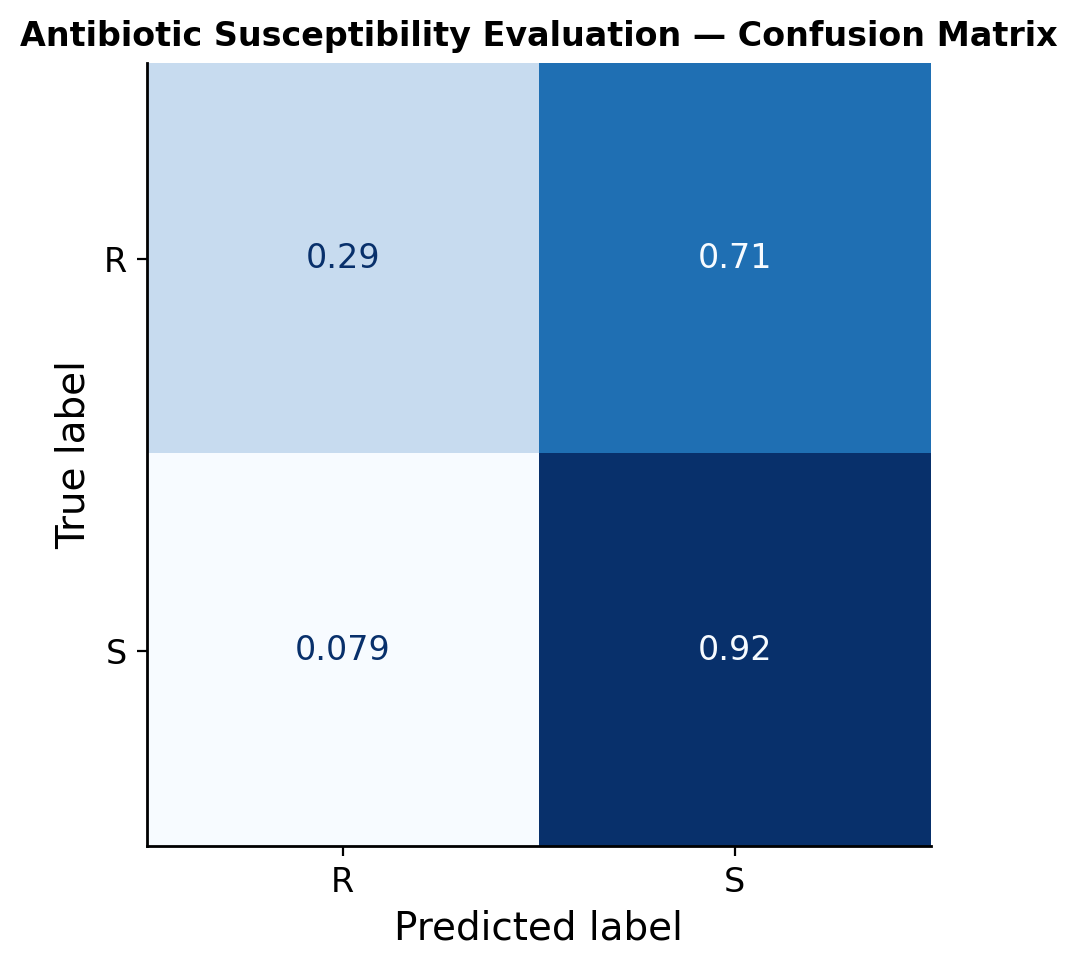

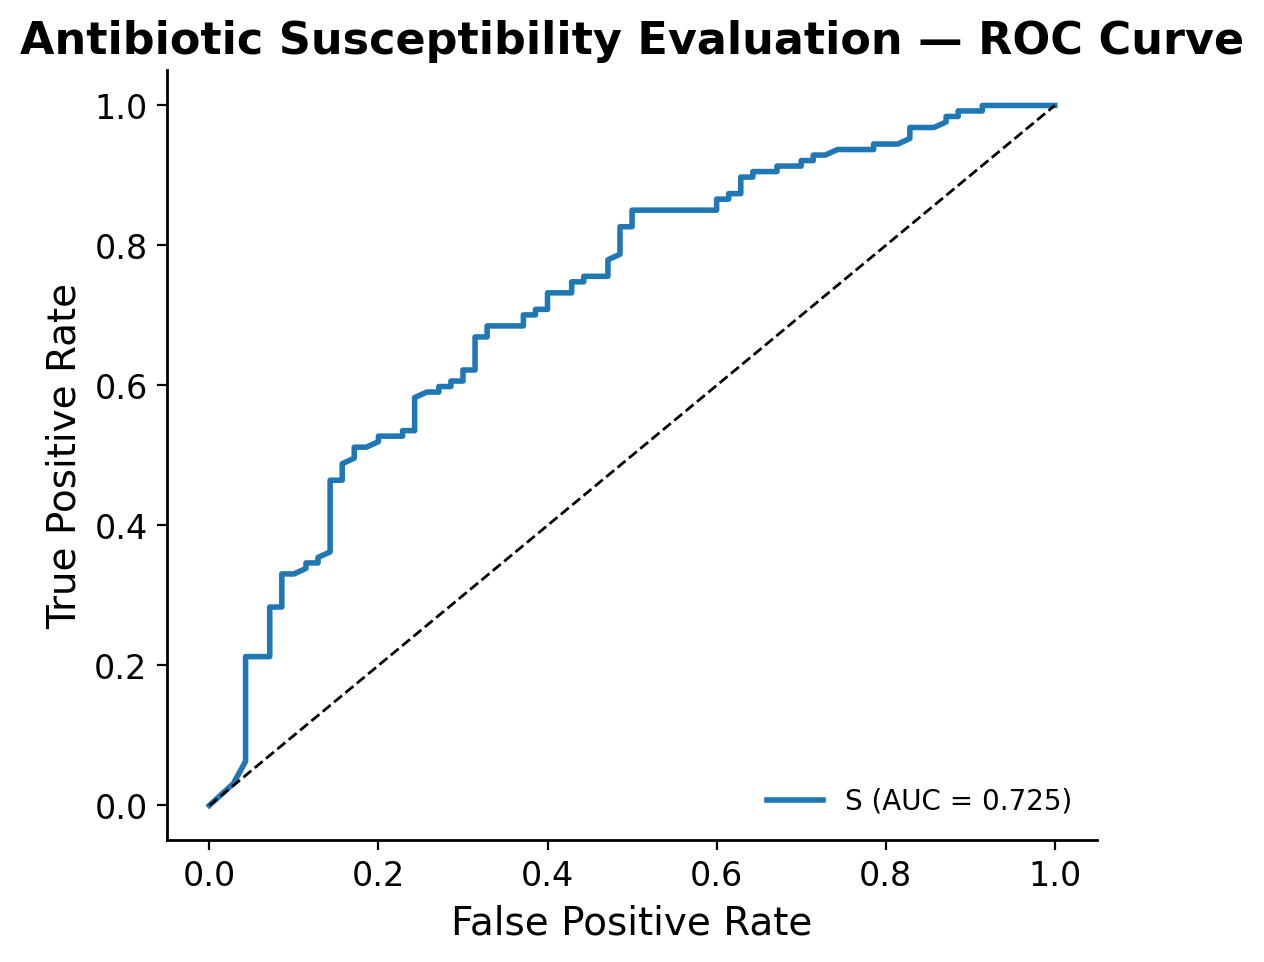

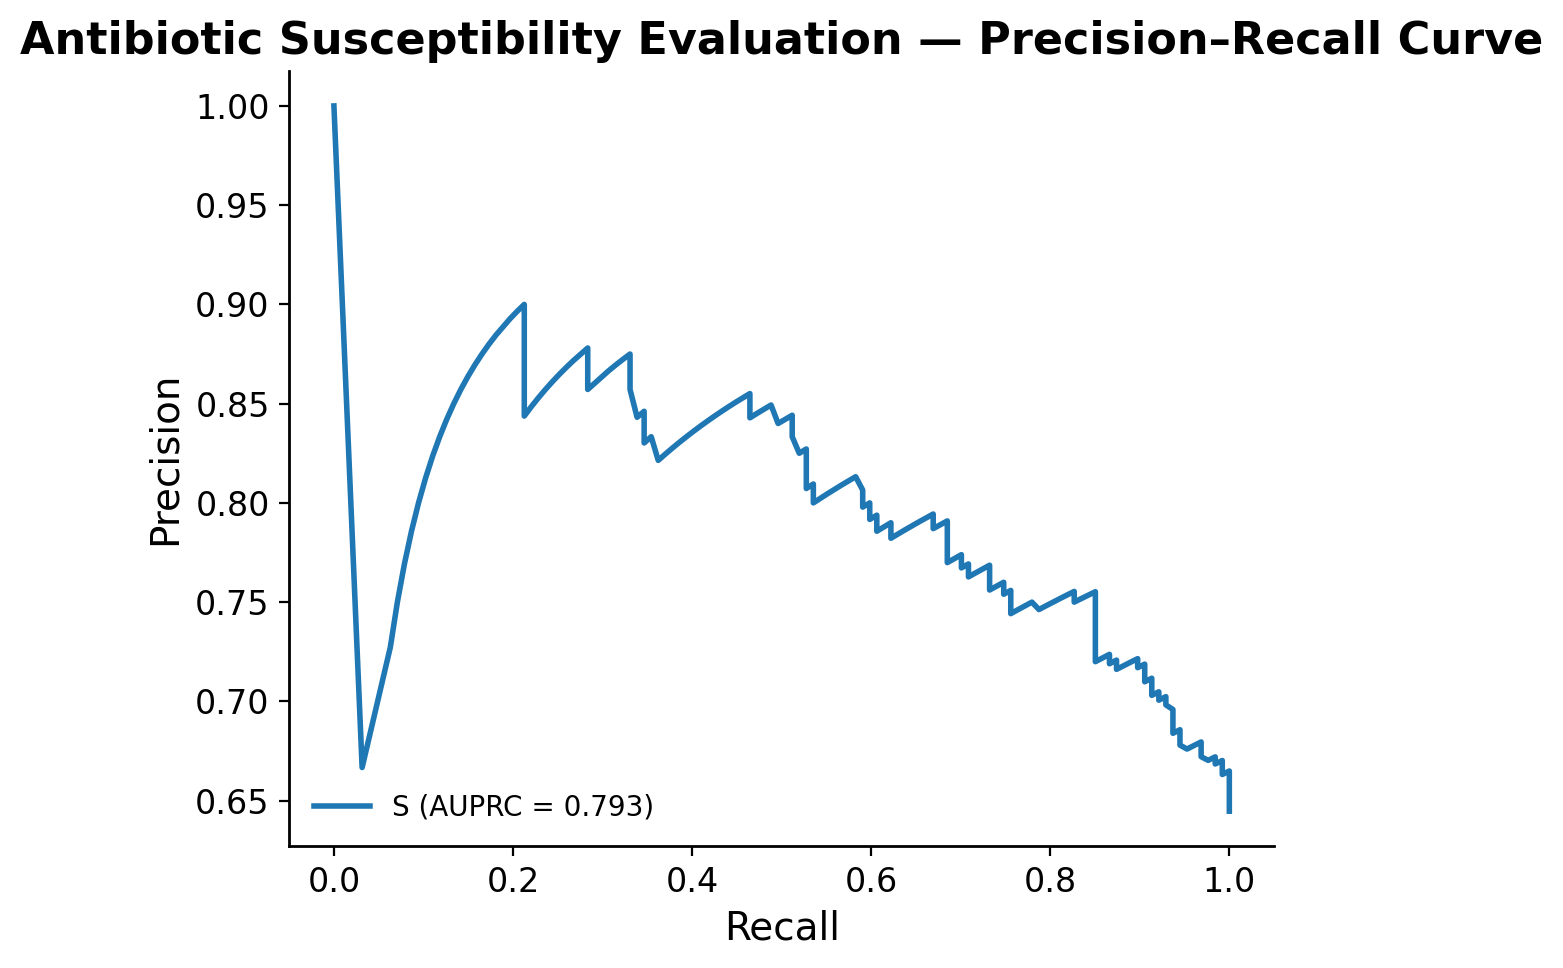

In [30]:
# Example usage
y_pred = pipe.predict(X_test)
y_score = pipe.predict_proba(X_test)

metrics, cm, fig_cm, fig_roc, fig_pr = evaluate_classifier(
    y_true=y_test["susceptible"].values,  # or your actual label column
    y_pred=y_pred,
    y_score=y_score,
    labels=pipe.classes_,  # ensures correct order
    title="Antibiotic Susceptibility Evaluation"
)



In [41]:
# Predict
y_pred = pipe.predict(X_test)
y_score = pipe.predict_proba(X_test)  # shape (n_samples, n_classes)

# Evaluate
metrics, cm, fig_cm, fig_roc, fig_pr = evaluate_classifier(
    y_true=y_test["susceptible"].values,
    y_pred=y_pred,
    y_score=y_score,
    labels=pipe.classes_,
    cm_normalize="true",
    title="Antibiotic Susceptibility Evaluation"
)

# Print metrics
print("\n--- Overall Metrics ---")
for k, v in metrics.items():
    if isinstance(v, float):
        print(f"{k:>12}: {v:.3f}")

print("\n--- Per-Class Metrics ---")
for cls, vals in metrics.get("per_class", {}).items():
    print(f"{cls:>3} → AUROC: {vals['AUROC']:.3f}, AUPRC: {vals['AUPRC']:.3f}")

# Show plots
plt.show()
plt.savefig("roc_curve.png")

ValueError: y_true takes value in {'R', 'S'} and pos_label is not specified: either make y_true take value in {0, 1} or {-1, 1} or pass pos_label explicitly.

In [35]:
# # save model 
# import joblib

# # Save the trained pipeline
# joblib.dump(pipe, "antibiotic_susceptibility_model.pkl")

# print("Model saved successfully!")


In [ ]:
# #load model
# # Load the trained model
# import joblib
# loaded_pipe = joblib.load("antibiotic_susceptibility_model.pkl")

# print("✅ Model loaded successfully!")

✅ Model loaded successfully!


In [ ]:
!pip install shap

  Using cached shap-0.49.1-cp313-cp313-macosx_11_0_arm64.whl.metadata (25 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached numba-0.62.1-cp313-cp313-macosx_12_0_arm64.whl.metadata (2.8 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
  Using cached llvmlite-0.45.1-cp313-cp313-macosx_12_0_arm64.whl.metadata (4.8 kB)
Using cached shap-0.49.1-cp313-cp313-macosx_11_0_arm64.whl (555 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached numba-0.62.1-cp313-cp313-macosx_12_0_arm64.whl (2.7 MB)
Using cached llvmlite-0.45.1-cp313-cp313-macosx_12_0_arm64.whl (37.3 MB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
   25l━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/5 [llvmlite]━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━ 3/5 [numba]━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━ 3/5 [numba]━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━ 3/5 [numba]━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━ 3/5 [numba]━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━ 3

In [37]:
import numpy as np
import scipy.sparse
import shap

# Extract preprocessor and model
preprocessor = pipe.named_steps["pre"]
model = pipe.named_steps["model"]

# Transform test set
X_test_transformed = preprocessor.transform(X_test)

# Convert sparse matrix (if needed)
if scipy.sparse.issparse(X_test_transformed):
    X_test_transformed = X_test_transformed.toarray()

# Ensure numeric dtype
X_test_transformed = X_test_transformed.astype(float)

# Get feature names
try:
    feature_names = preprocessor.get_feature_names_out()
except:
    feature_names = [f"f{i}" for i in range(X_test_transformed.shape[1])]


In [38]:
# Define mapping between encoded labels and actual class names
class_mapping = {
    0: "Susceptible (S)",
    1: "Intermediate (I)",
    2: "Resistant (R)"
}





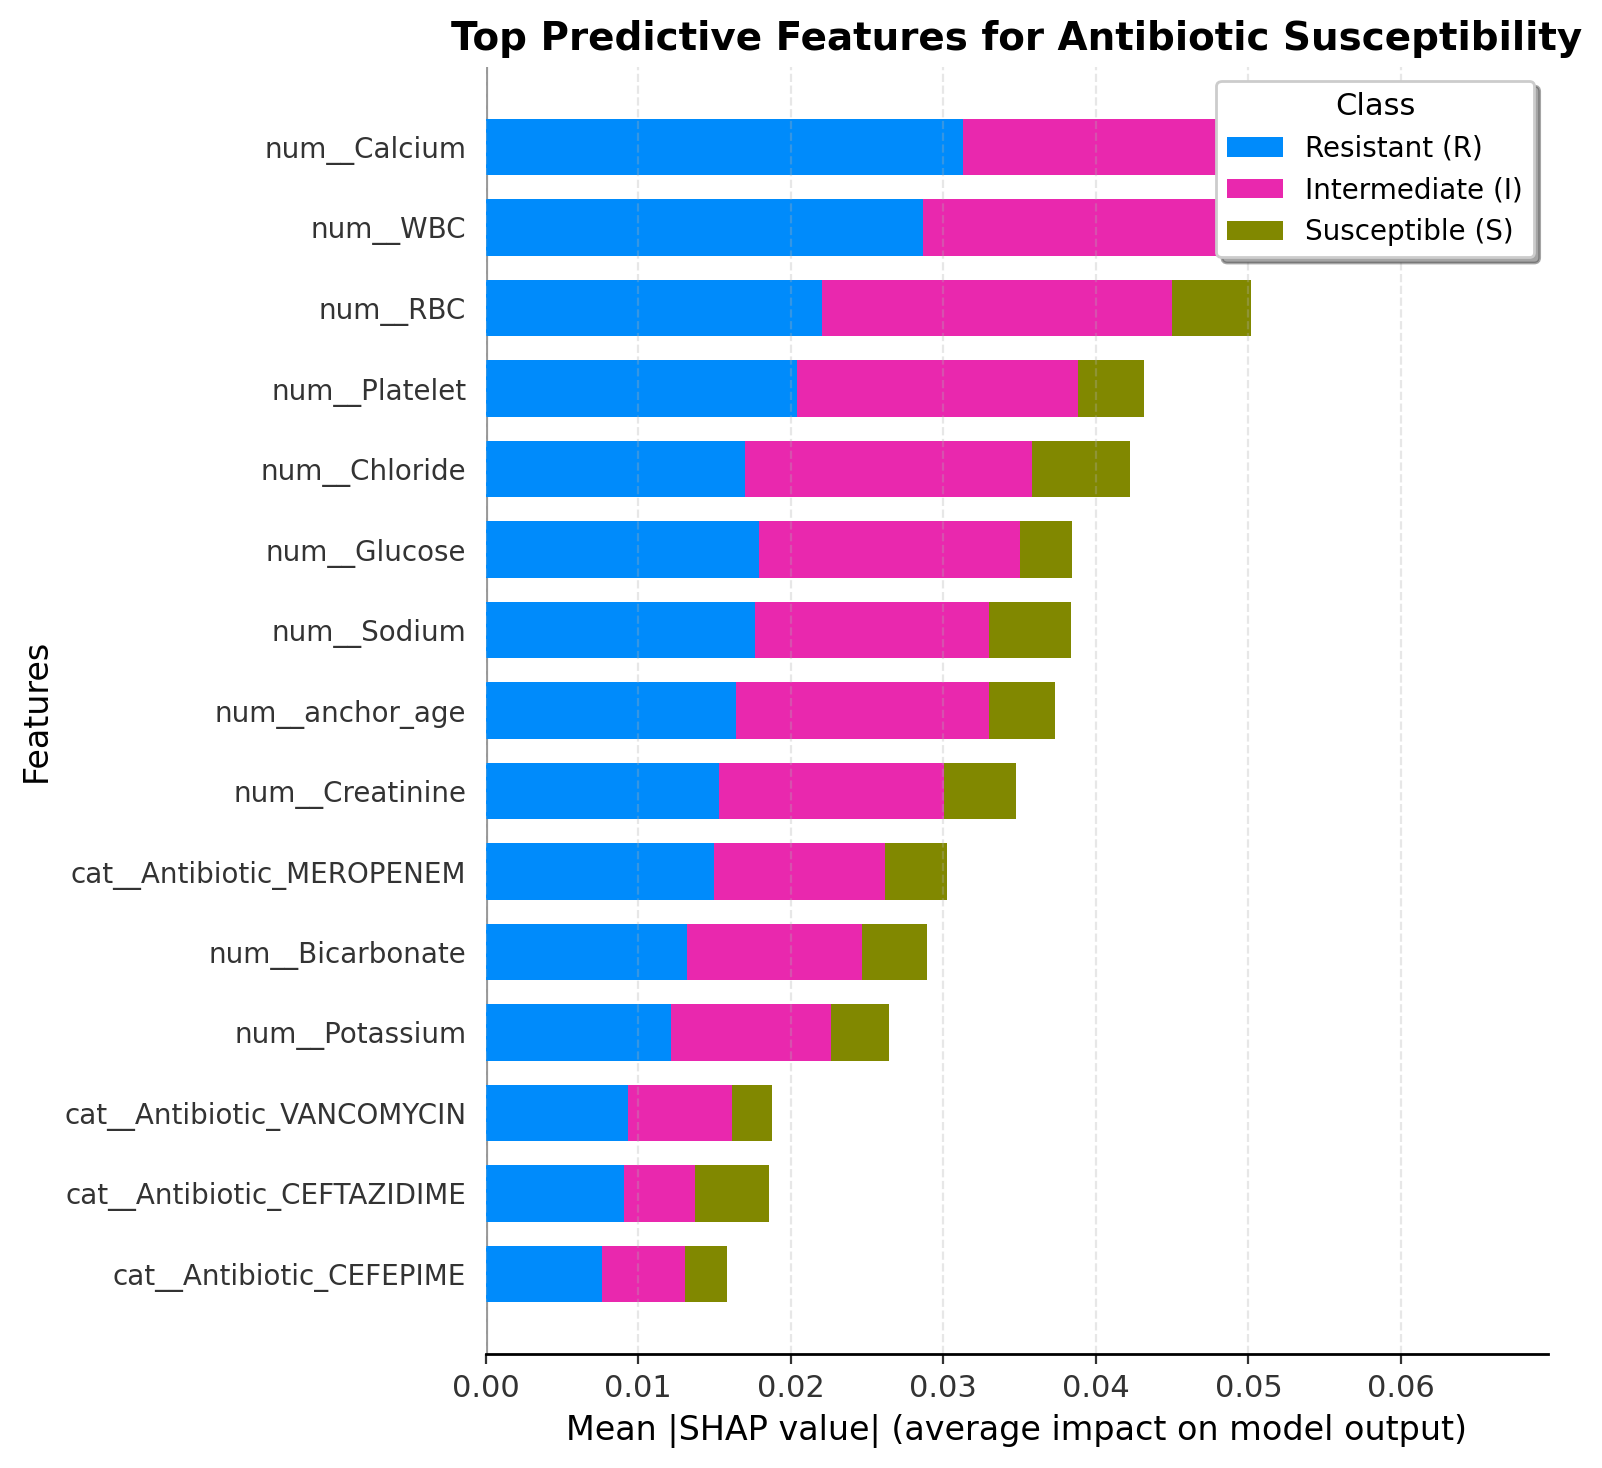

In [39]:
explainer = shap.Explainer(model)
shap_values = explainer(X_test_transformed)
shap.summary_plot(shap_values,
                 X_test_transformed,
                 feature_names=feature_names,
                 class_names=[class_mapping[i] for i in range(len(class_mapping))],
                 plot_type="bar",
                color_bar=True,
    max_display=15,  # show top 15 features
    show=False       # suppress default display to allow styling
)

# --- Beautify ---
plt.title("Top Predictive Features for Antibiotic Susceptibility", fontsize=14, weight='bold')
plt.xlabel("Mean |SHAP value| (average impact on model output)", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=10)
plt.grid(alpha=0.3, linestyle="--", axis='x')

# --- Adjust legend position ---
plt.legend(
    loc="upper right",
    title="Class",
    fontsize=10,
    title_fontsize=11,
    frameon=True,
    shadow=True
)

plt.tight_layout()
plt.show()

In [48]:
# Select class index — e.g., 'Susceptible'
class_idx = 1  # change based on your label order

# Beeswarm plot
shap.plots.beeswarm(
    shap.Explanation(
        values=shap_values[class_idx],
        base_values=explainer.expected_value[class_idx],
        data=X_test_transformed,
        feature_names=feature_names,
    ),
    max_display=10  # top 10 most important features
)


DimensionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

In [ ]:
# from typing import Any, Dict, Optional, Tuple
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.metrics import (
#     roc_curve,
#     precision_recall_curve,
#     roc_auc_score,
#     auc,
#     confusion_matrix,
#     ConfusionMatrixDisplay,
#     accuracy_score,
#     precision_score,
#     recall_score,
#     f1_score,
# )

# def evaluate_binary_classifier(
#     y_true: np.ndarray,
#     y_pred: Optional[np.ndarray] = None,
#     y_score: Optional[np.ndarray] = None,
#     pos_label: Any = 1,
#     plot_cm: bool = True,
#     cm_normalize: Optional[str] = None,  # None, 'true', 'pred', or 'all'
#     title: str = "Confusion Matrix",
# ) -> Tuple[Dict[str, float], np.ndarray, Optional[plt.Figure], Optional[plt.Figure], Optional[plt.Figure]]:
#     """
#     Evaluate a binary classifier: AUROC, PR AUC, confusion matrix, specificity,
#     sensitivity, accuracy, precision, recall, and F1 score.
#     Optionally plots the confusion matrix, ROC curve, and PR curve.

#     Returns
#     -------
#     metrics : dict
#         {'auroc', 'pr_auc', 'specificity', 'sensitivity', 'accuracy', 'precision', 'recall', 'f1'}
#     cm : ndarray
#         Confusion matrix [[TN, FP], [FN, TP]]
#     fig_cm : matplotlib.figure.Figure or None
#         Confusion matrix figure
#     fig_roc : matplotlib.figure.Figure or None
#         ROC curve figure
#     fig_pr : matplotlib.figure.Figure or None
#         Precision–Recall curve figure
#     """
#     y_true = np.asarray(y_true)

#     # Ensure binary problem
#     unique = np.unique(y_true)
#     if unique.size != 2:
#         raise ValueError(f"Binary classification only; found labels: {unique!r}")
#     if pos_label not in unique:
#         raise ValueError(f"pos_label={pos_label!r} not found in y_true labels {unique!r}")

#     neg_label = unique[0] if unique[1] == pos_label else unique[1]
#     labels_order = [neg_label, pos_label]

#     # Build y_pred if not provided
#     if y_pred is None:
#         if y_score is None:
#             raise ValueError("Must provide y_pred or y_score.")
#         y_pred = (np.asarray(y_score) >= 0.5).astype(type(pos_label))

#     y_pred = np.asarray(y_pred)
#     if y_score is not None:
#         y_score = np.asarray(y_score)

#     # Confusion matrix
#     cm_counts = confusion_matrix(y_true, y_pred, labels=labels_order)
#     tn, fp, fn, tp = cm_counts.ravel()

#     # Metrics
#     specificity = tn / (tn + fp) if (tn + fp) else 0.0
#     sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
#     accuracy = accuracy_score(y_true, y_pred)
#     precision = precision_score(y_true, y_pred, pos_label=pos_label, zero_division=0)
#     recall = recall_score(y_true, y_pred, pos_label=pos_label, zero_division=0)
#     f1 = f1_score(y_true, y_pred, pos_label=pos_label, zero_division=0)

#     # AUROC & PR AUC
#     auroc = None
#     pr_auc = None
#     if y_score is not None:
#         auroc = roc_auc_score(y_true, y_score)
#         prec_curve, rec_curve, _ = precision_recall_curve(y_true, y_score, pos_label=pos_label)
#         pr_auc = auc(rec_curve, prec_curve)

#     metrics = {
#         "auroc": float(auroc) if auroc is not None else None,
#         "pr_auc": float(pr_auc) if pr_auc is not None else None,
#         "specificity": float(specificity),
#         "sensitivity": float(sensitivity),
#         "accuracy": float(accuracy),
#         "precision": float(precision),
#         "recall": float(recall),
#         "f1": float(f1),
#     }

#     # Plot figures
#     fig_cm = fig_roc = fig_pr = None

#     # 1️⃣ Confusion matrix
#     if plot_cm:
#         disp = ConfusionMatrixDisplay(
#             confusion_matrix(y_true, y_pred, labels=labels_order, normalize=cm_normalize),
#             display_labels=labels_order,
#         )
#         fig_cm, ax = plt.subplots(figsize=(4.5, 4))
#         disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format=".2f" if cm_normalize else "d")
#         ax.set_title(title)
#         ax.set_xlabel("Predicted")
#         ax.set_ylabel("Actual")
#         fig_cm.tight_layout()

#     # 2️⃣ ROC curve
#     if y_score is not None:
#         fpr, tpr, _ = roc_curve(y_true, y_score, pos_label=pos_label)
#         fig_roc, ax_roc = plt.subplots(figsize=(5, 4))
#         ax_roc.plot(fpr, tpr, label=f"AUROC = {auroc:.3f}")
#         ax_roc.plot([0, 1], [0, 1], "k--", label="Chance")
#         ax_roc.set_xlabel("False Positive Rate")
#         ax_roc.set_ylabel("True Positive Rate")
#         ax_roc.set_title("ROC Curve")
#         ax_roc.legend()
#         fig_roc.tight_layout()

#         # 3️⃣ Precision–Recall curve
#         fig_pr, ax_pr = plt.subplots(figsize=(5, 4))
#         ax_pr.plot(rec_curve, prec_curve, label=f"PR AUC = {pr_auc:.3f}")
#         ax_pr.set_xlabel("Recall")
#         ax_pr.set_ylabel("Precision")
#         ax_pr.set_title("Precision–Recall Curve")
#         ax_pr.legend()
#         fig_pr.tight_layout()

#     return metrics, cm_counts, fig_cm, fig_roc, fig_pr


In [64]:
# # Extract probabilities for 'susceptible'
# proba_list = pipe.predict_proba(X_test)
# y_score = proba_list[1][:, 1]  # binary probabilities for 'susceptible'

# # Evaluate
# metrics, cm, fig_cm, fig_roc, fig_pr = evaluate_binary_classifier(
#     y_true=y_test["susceptible"].values,
#     y_pred=pred_df["susceptible"].values,
#     y_score=y_score,
#     pos_label=1,
#     plot_cm=True,
#     title="Susceptible Confusion Matrix"
# )

# # Print metrics
# print("\n--- Binary Classification Metrics for 'Susceptible' ---")
# for k, v in metrics.items():
#     print(f"{k:15s}: {v:.3f}" if v is not None else f"{k:15s}: None")

# # Show plots
# for fig in [fig_cm, fig_roc, fig_pr]:
#     if fig is not None:
#         plt.show()


# Multiclass evaluation (S/I/R)
Use this helper to evaluate 3-class predictions (S, I, R). It reports accuracy, macro/weighted metrics, confusion matrix, and macro AUROC/PR AUC if class probabilities are provided.

In [68]:
from typing import Any, Dict, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
)


def evaluate_multiclass_classifier(
    y_true: np.ndarray,
    y_pred: Optional[np.ndarray] = None,
    y_score: Optional[np.ndarray] = None,
    labels: Optional[List[Any]] = None,  # e.g., ['S','I','R'] in desired order
    average: str = "macro",             # 'macro' | 'weighted' | 'micro'
    plot_cm: bool = True,
    cm_normalize: Optional[str] = None,  # None | 'true' | 'pred' | 'all'
    title: str = "Confusion Matrix (S/I/R)",
) -> Tuple[Dict[str, Any], np.ndarray, Optional[plt.Figure]]:
    """
    Evaluate a 3-class classifier (e.g., S/I/R): accuracy, per-class metrics, macro/weighted summaries,
    confusion matrix, and macro AUROC / macro PR AUC if class probabilities are provided.

    y_true: array-like of labels
    y_pred: discrete predictions; if None and y_score is given, uses argmax over y_score
    y_score: probabilities/scores of shape (n_samples, n_classes) aligned to `labels` order
    labels: explicit label order; inferred from y_true if not provided
    average: averaging strategy for AUROC/PR AUC (macro by default)
    """
    y_true = np.asarray(y_true)

    # Determine label order
    if labels is None:
        labels = list(pd.Index(np.unique(y_true)).tolist())
    n_classes = len(labels)

    # Build y_pred if needed
    if y_pred is None:
        if y_score is None:
            raise ValueError("Provide y_pred or y_score (probabilities) for evaluation.")
        y_pred_idx = np.argmax(y_score, axis=1)
        y_pred = np.array([labels[i] for i in y_pred_idx])
    else:
        y_pred = np.asarray(y_pred)

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    # Accuracy and detailed report
    acc = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred, labels=labels, output_dict=True, zero_division=0)

    # AUROC / PR AUC (macro) if probabilities available
    auroc_macro = pr_auc_macro = None
    if y_score is not None:
        # Map y_true to integer indices per labels order
        y_true_idx = pd.Categorical(y_true, categories=labels, ordered=True).codes
        # roc_auc_score supports multi_class OVR/OVO; use OVR by default
        try:
            auroc_macro = roc_auc_score(y_true_idx, y_score, multi_class="ovr", average=average)
        except Exception:
            auroc_macro = None
        try:
            # Macro average precision across classes
            pr_auc_macro = average_precision_score(pd.get_dummies(y_true_idx), y_score, average=average)
        except Exception:
            pr_auc_macro = None

    # Prepare metrics summary
    metrics: Dict[str, Any] = {
        "labels": labels,
        "accuracy": float(acc),
        "macro_precision": float(report.get("macro avg", {}).get("precision", np.nan)),
        "macro_recall": float(report.get("macro avg", {}).get("recall", np.nan)),
        "macro_f1": float(report.get("macro avg", {}).get("f1-score", np.nan)),
        "weighted_f1": float(report.get("weighted avg", {}).get("f1-score", np.nan)),
        "per_class": {lbl: {
            "precision": float(report.get(lbl, {}).get("precision", np.nan)),
            "recall": float(report.get(lbl, {}).get("recall", np.nan)),
            "f1": float(report.get(lbl, {}).get("f1-score", np.nan)),
            "support": int(report.get(lbl, {}).get("support", 0)),
        } for lbl in labels},
        "auroc_macro_ovr": float(auroc_macro) if auroc_macro is not None else None,
        "pr_auc_macro": float(pr_auc_macro) if pr_auc_macro is not None else None,
    }

    fig = None
    if plot_cm:
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
        fig, ax = plt.subplots(figsize=(5, 4))
        disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format=".2f" if cm_normalize else "d", normalize=cm_normalize)
        ax.set_title(title)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        fig.tight_layout()

    return metrics, cm, fig

TypeError: ConfusionMatrixDisplay.plot() got an unexpected keyword argument 'normalize'

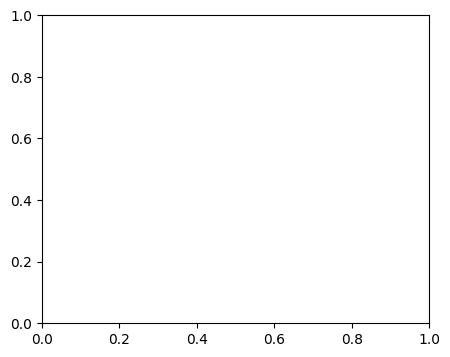

In [69]:
evaluate_multiclass_classifier(
    y_true=y_test["susceptible"].values,
    y_pred=pred_df["susceptible"].values,
    y_score=y_score,
    labels=[ 'S','I','R'],)